In [4]:
print("Kel : My Little Bolu Ketan")
print("Kelas : IF-48-06")
print("Judul : Penerapan Sistem Inferensi Fuzzy Sugeno dan Mamdani untuk Mengestimasi Harga Jual")
print("        Mobil Bekas Toyota Berdasarkan Karakteristik Spesifikasi Kendaraan ")

Kel : My Little Bolu Ketan
Kelas : IF-48-06
Judul : Penerapan Sistem Inferensi Fuzzy Sugeno dan Mamdani untuk Mengestimasi Harga Jual
        Mobil Bekas Toyota Berdasarkan Karakteristik Spesifikasi Kendaraan 


In [32]:
import pandas as pd

# 1. Membaca dataset dan konversi kurs ke rupiah
df = pd.read_csv('toyota.csv')
kurs_rupiah = 18000
df['price'] = df['price'] * kurs_rupiah
df['tax'] = df['tax'] * kurs_rupiah

# Konversi kolom mileage dari mil ke kilometer
df['mileage'] = df['mileage'] * 1.60934

# statistik deskriptif 
desc = df[['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']].describe()

# memindahkan baris 'mean' ke paling bawah
urutan_baru = ['count', 'std', 'min', '25%', '50%', '75%', 'max', 'mean']
desc = desc.reindex(urutan_baru)

# Membuat DataFrame baru khusus untuk tampilan estetik
df_menarik = pd.DataFrame(index=desc.index, columns=desc.columns)

for col in desc.columns:
    for idx in desc.index:
        nilai = desc.loc[idx, col]
        
        # Bulat murni tanpa titik/koma
        if idx == 'count':
            df_menarik.loc[idx, col] = f"{nilai:.0f}"
            
        # Menggunakan pembulatan matematika (.0f)
        elif col == 'year':
            df_menarik.loc[idx, col] = f"{nilai:.2f}" if idx == 'std' else f"{nilai:.0f}"
            
        # pemisah ribuan koma, termasuk mileage_km 
        elif col in ['mileage', 'tax', 'price']:
            df_menarik.loc[idx, col] = f"{nilai:,.0f}"
            
        # Kolom Desimal
        elif col == 'mpg':
            df_menarik.loc[idx, col] = f"{nilai:.2f}"
        elif col == 'engineSize':
            df_menarik.loc[idx, col] = f"{nilai:.1f}"

# 5. Tampilkan hasil akhir dengan style rapi
df_menarik.style.set_properties(**{
    'text-align': 'center',
    'padding': '10px'
})

# NOTE :
# mpg/mil per galon =  2.80 (1,19km/liter)
# engineSize = 1.0 liter (1000 CC)

,year,mileage,tax,mpg,engineSize,price
count,6738,6738,6738,6738,6738,6738
std,2.20,"30,779","1,329,854",15.84,0.4,"114,210,317"
min,1998,3,0,2.80,0.0,"15,300,000"
25%,2016,"15,202",0,55.40,1.0,"149,220,000"
50%,2017,"29,794","2,430,000",62.80,1.5,"194,310,000"
75%,2018,"49,992","2,610,000",69.00,1.8,"269,910,000"
max,2020,"280,699","10,170,000",235.00,4.5,"1,079,910,000"
mean,2017,"36,785","1,704,550",63.04,1.5,"225,403,039"


# III. IMPLEMENTASI SISTEM LOGIKA FUZZY

Berdasarkan hasil analisis statistik deskriptif data riil (Tabel 2), berikut adalah parameter batas-batas linguistik kurva keanggotaan yang dirancang untuk proses fuzzifikasi:

| Variabel | Himpunan Linguistik | Bentuk Kurva | Batasan Domain (Angka) |
| :--- | :--- | :--- | :--- |
| **year** | Lama <br> Sedang <br> Baru | Trapesium kiri <br> Segitiga <br> Trapesium kanan | [1998, 1998, 2016, 2017] <br> [2016, 2017, 2018] <br> [2017, 2018, 2020, 2020] |
| **mileage** | Rendah <br> Sedang <br> Tinggi | Trapesium kiri <br> Segitiga <br> Trapesium kanan | [3, 3, 15202, 29794] <br> [15202, 29794, 49992] <br> [29794, 49992, 280699, 280699] |
| **tax** | Murah <br> Normal <br> Mahal | Trapesium kiri <br> Segitiga <br> Trapesium kanan | [0, 0, 0, 2430000] <br> [0, 2430000, 2610000] <br> [2430000, 2610000, 10170000, 10170000] |
| **mpg** | Boros <br> Irit <br> Sangat Irit | Trapesium kiri <br> Segitiga <br> Trapesium kanan | [2.80, 2.80, 55.40, 62.80] <br> [55.40, 62.80, 69.00] <br> [62.80, 69.00, 235.00, 235.00] |
| **engineSize** | Kecil <br> Sedang <br> Besar | Trapesium kiri <br> Segitiga <br> Trapesium kanan | [0.0, 0.0, 1.0, 1.5] <br> [1.0, 1.5, 1.8] <br> [1.5, 1.8, 4.5, 4.5] |
| **price (Output)** | Murah <br> Sedang <br> Mahal | Trapesium kiri <br> Segitiga <br> Trapesium kanan | [15300000, 15300000, 149220000, 194310000] <br> [149220000, 194310000, 269910000] <br> [194310000, 269910000, 1079910000, 1079910000] |

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport (tanpa skfuzzy)!")

✅ Library berhasil diimport (tanpa skfuzzy)!


In [34]:
# ============================================================
#  FUNGSI KEANGGOTAAN MANUAL (Versi Original + Diperbaiki)
# ============================================================
import numpy as np

def trapmf(x, a, b, c, d):
    x = np.atleast_1d(np.array(x, dtype=float))
    y = np.zeros_like(x)
    for i, xi in enumerate(x):
        # PENAMBAHAN: Atasi mentok kanan (Trapesium Kanan)
        if c == d and xi >= c:
            y[i] = 1.0
        # PENAMBAHAN: Atasi mentok kiri (Trapesium Kiri)
        elif a == b and xi <= a:
            y[i] = 1.0
            
        # LOGIKA ASLI KAMU DI BAWAH SINI:
        elif xi <= a or xi >= d:      
            y[i] = 0.0
        elif b <= xi <= c:           
            y[i] = 1.0
        elif a < xi < b:             
            y[i] = (xi - a) / (b - a) if (b - a) != 0 else 1.0
        elif c < xi < d:             
            y[i] = (d - xi) / (d - c) if (d - c) != 0 else 1.0
            
    return y if len(y) > 1 else float(y[0])


def trimf(x, a, b, c):
    x = np.atleast_1d(np.array(x, dtype=float))
    y = np.zeros_like(x)
    for i, xi in enumerate(x):
        # PENAMBAHAN: Atasi segitiga siku-siku mentok kiri
        if a == b and xi <= a:
            y[i] = 1.0
        # PENAMBAHAN: Atasi segitiga siku-siku mentok kanan
        elif b == c and xi >= c:
            y[i] = 1.0
            
        # LOGIKA ASLI KAMU DI BAWAH SINI:
        elif xi <= a or xi >= c:      
            y[i] = 0.0
        elif xi == b:                
            y[i] = 1.0
        elif a < xi <= b:            
            y[i] = (xi - a) / (b - a) if (b - a) != 0 else 1.0
        elif b < xi < c:             
            y[i] = (c - xi) / (c - b) if (c - b) != 0 else 1.0
            
    return y if len(y) > 1 else float(y[0])


def interp_mf(universe, mf_vals, x):
    # PENAMBAHAN: np.clip agar tidak error jika user masukin input kelewat batas
    x_clipped = np.clip(x, universe.min(), universe.max())
    return float(np.interp(x_clipped, universe, mf_vals))

In [35]:
# ============================================================
#  UNIVERSE OF DISCOURSE
# ============================================================

U_YEAR       = np.arange(1998, 2021, 1)
U_MILEAGE    = np.arange(0, 281000, 500)
U_TAX        = np.arange(0, 11_000_000, 10000)
U_MPG        = np.arange(2.8, 236.0, 0.2)
U_ENGINESIZE = np.arange(0.0, 4.6, 0.1)
U_PRICE      = np.arange(15_300_000, 1_090_000_000, 10000)

# ============================================================
#  FUNGSI KEANGGOTAAN TIAP VARIABEL
# ============================================================

MF = {
    # ---- year ----
    'year_Lama'   : trapmf(U_YEAR,  1998, 1998, 2016, 2017),
    'year_Sedang' : trimf( U_YEAR,  2016, 2017, 2018),
    'year_Baru'   : trapmf(U_YEAR,  2017, 2018, 2020, 2020),

    # ---- mileage ----
    'mil_Rendah'  : trapmf(U_MILEAGE, 0, 0, 15202, 29794),
    'mil_Sedang'  : trimf( U_MILEAGE, 15202, 29794, 49992),
    'mil_Tinggi'  : trapmf(U_MILEAGE, 29794, 49992, 280699, 280699),

    # ---- tax ----
    'tax_Murah'   : trapmf(U_TAX, 0, 0, 0, 2_430_000),
    'tax_Normal'  : trimf( U_TAX, 0, 2_430_000, 2_610_000),
    'tax_Mahal'   : trapmf(U_TAX, 2_430_000, 2_610_000, 10_170_000, 10_170_000),

    # ---- mpg ----
    'mpg_Boros'      : trapmf(U_MPG, 2.8, 2.8, 55.4, 62.8),
    'mpg_Irit'       : trimf( U_MPG, 55.4, 62.8, 69.0),
    'mpg_SangatIrit' : trapmf(U_MPG, 62.8, 69.0, 235.0, 235.0),

    # ---- engineSize ----
    'eng_Kecil'   : trapmf(U_ENGINESIZE, 0.0, 0.0, 1.0, 1.5),
    'eng_Sedang'  : trimf( U_ENGINESIZE, 1.0, 1.5, 1.8),
    'eng_Besar'   : trapmf(U_ENGINESIZE, 1.5, 1.8, 4.5, 4.5),

    # ---- price (output) ----
    'price_Murah'  : trapmf(U_PRICE, 15_300_000, 15_300_000, 149_220_000, 194_310_000),
    'price_Sedang' : trimf( U_PRICE, 149_220_000, 194_310_000, 269_910_000),
    'price_Mahal'  : trapmf(U_PRICE, 194_310_000, 269_910_000, 1_079_910_000, 1_079_910_000),
}

print("✅ Semua fungsi keanggotaan berhasil dihitung!")
print(f"   Total titik universe price : {len(U_PRICE):,}")

✅ Semua fungsi keanggotaan berhasil dihitung!
   Total titik universe price : 107,470


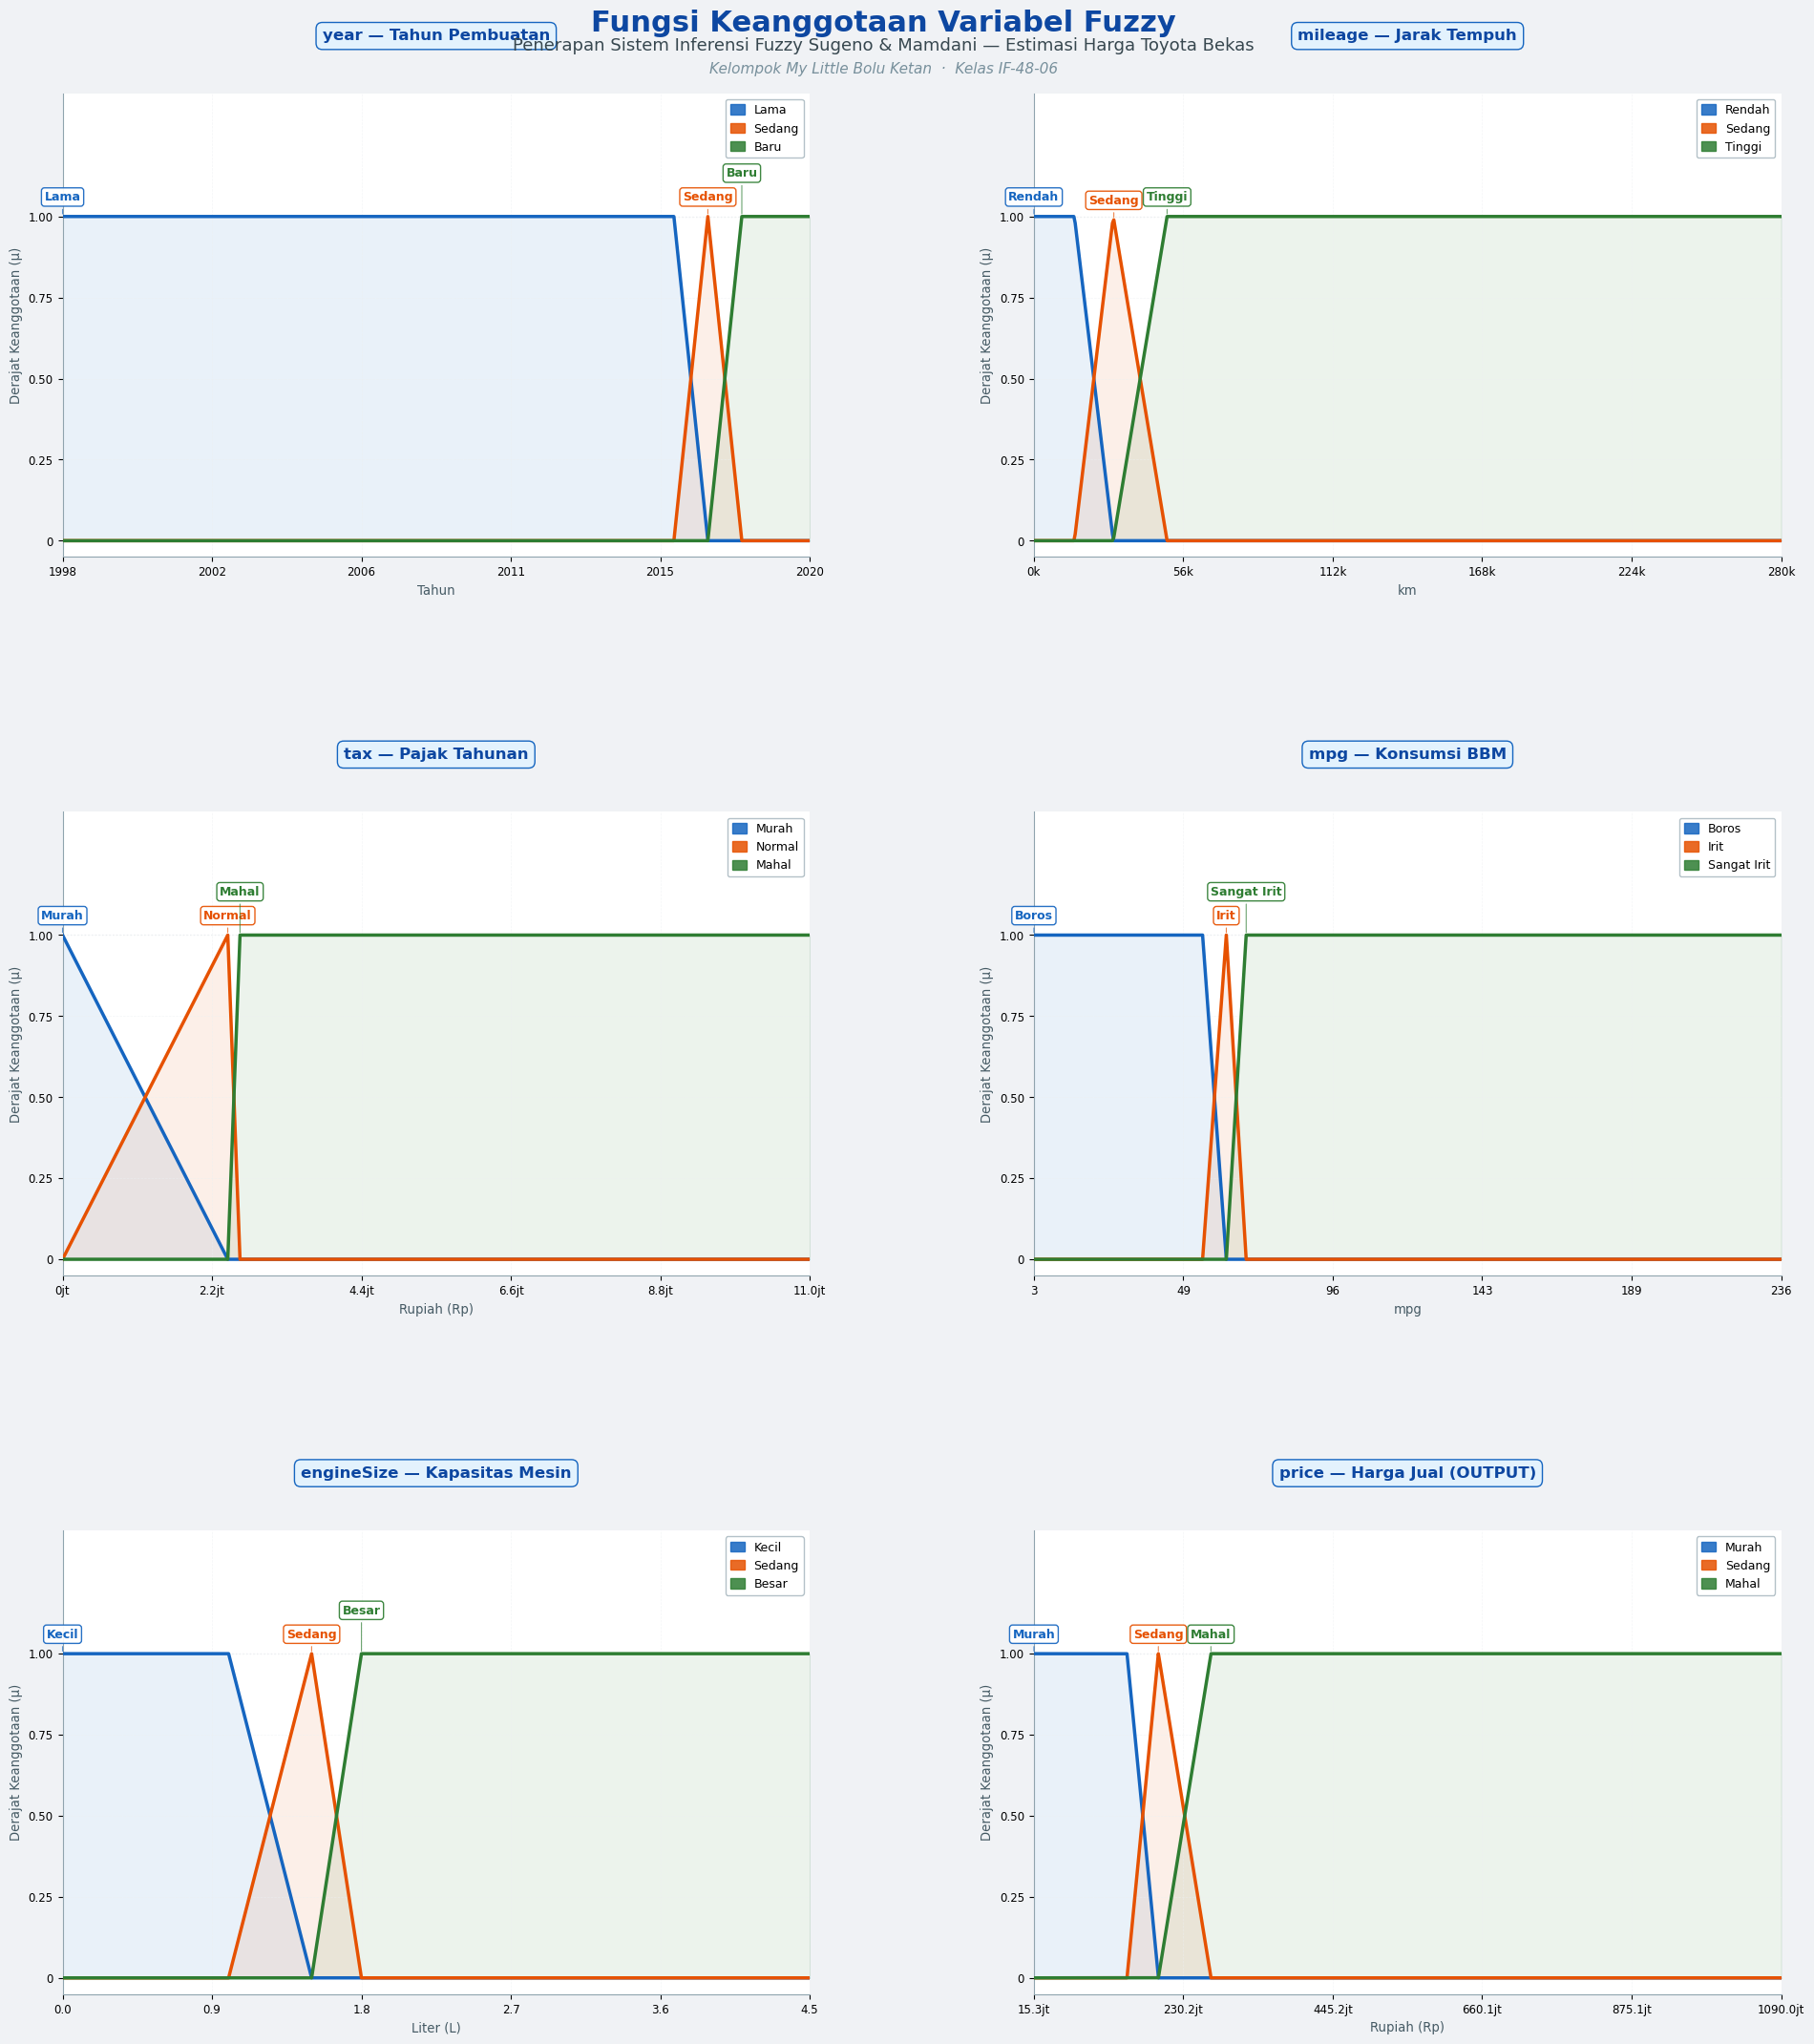

✅ Grafik tersimpan: 'fungsi_keanggotaan.png'


In [36]:
def fmt_juta(v):
    n = v / 1_000_000
    return f'{int(n)}jt' if n == int(n) else f'{n:.1f}jt'

WARNA     = ['#1565C0', '#E65100', '#2E7D32']
ALPHA_ISI = 0.09

konfig = [
    (U_YEAR,       'year — Tahun Pembuatan',
     [('Lama','year_Lama'),('Sedang','year_Sedang'),('Baru','year_Baru')],
     lambda v: str(int(v)), 'Tahun'),

    (U_MILEAGE,    'mileage — Jarak Tempuh',
     [('Rendah','mil_Rendah'),('Sedang','mil_Sedang'),('Tinggi','mil_Tinggi')],
     lambda v: f'{int(v/1000)}k', 'km'),

    (U_TAX,        'tax — Pajak Tahunan',
     [('Murah','tax_Murah'),('Normal','tax_Normal'),('Mahal','tax_Mahal')],
     fmt_juta, 'Rupiah (Rp)'),

    (U_MPG,        'mpg — Konsumsi BBM',
     [('Boros','mpg_Boros'),('Irit','mpg_Irit'),('Sangat Irit','mpg_SangatIrit')],
     lambda v: f'{v:.0f}', 'mpg'),

    (U_ENGINESIZE, 'engineSize — Kapasitas Mesin',
     [('Kecil','eng_Kecil'),('Sedang','eng_Sedang'),('Besar','eng_Besar')],
     lambda v: f'{v:.1f}', 'Liter (L)'),

    (U_PRICE,      'price — Harga Jual (OUTPUT)',
     [('Murah','price_Murah'),('Sedang','price_Sedang'),('Mahal','price_Mahal')],
     fmt_juta, 'Rupiah (Rp)'),
]

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#F0F2F5')

fig.text(0.5, 0.985, 'Fungsi Keanggotaan Variabel Fuzzy',
         ha='center', va='top', fontsize=22,
         fontweight='bold', color='#0D47A1')
fig.text(0.5, 0.972,
         'Penerapan Sistem Inferensi Fuzzy Sugeno & Mamdani — Estimasi Harga Toyota Bekas',
         ha='center', va='top', fontsize=13, color='#37474F')
fig.text(0.5, 0.960,
         'Kelompok My Little Bolu Ketan  ·  Kelas IF-48-06',
         ha='center', va='top', fontsize=11, color='#78909C', style='italic')

gs = GridSpec(3, 2, figure=fig,
              top=0.945, bottom=0.04,
              hspace=0.55, wspace=0.30,
              left=0.07, right=0.97)

for idx, (univ, judul, himpunan, fmt_x, xlabel) in enumerate(konfig):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    ax.set_facecolor('#FFFFFF')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6, color='#ECEFF1')
    for sp in ['top','right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#90A4AE')
    ax.spines['bottom'].set_color('#90A4AE')

    label_xs = []
    for i, (nama, key) in enumerate(himpunan):
        mf_vals = MF[key]
        ax.plot(univ, mf_vals, color=WARNA[i],
                linewidth=2.5, label=nama, zorder=3)
        ax.fill_between(univ, mf_vals,
                        alpha=ALPHA_ISI, color=WARNA[i])

        puncak_i = int(np.argmax(mf_vals))
        px = univ[puncak_i]
        py = float(mf_vals[puncak_i])

        # cegah label tumpang tindih
        offset_y = 10
        for lx in label_xs:
            if abs(px - lx) < (univ[-1] - univ[0]) * 0.07:
                offset_y += 18
                break
        label_xs.append(px)

        if py > 0.05:
            ax.annotate(nama,
                        xy=(px, py),
                        xytext=(0, offset_y),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=9, fontweight='bold',
                        color=WARNA[i],
                        bbox=dict(boxstyle='round,pad=0.25',
                                  fc='white', ec=WARNA[i],
                                  lw=1, alpha=0.92),
                        arrowprops=dict(arrowstyle='-',
                                        color=WARNA[i],
                                        lw=0.8, alpha=0.7))

    ax.set_xlim(univ[0], univ[-1])
    ticks = np.linspace(univ[0], univ[-1], 6)
    ax.set_xticks(ticks)
    ax.set_xticklabels([fmt_x(v) for v in ticks], fontsize=8.5)
    ax.set_ylim(-0.05, 1.38)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0','0.25','0.50','0.75','1.00'], fontsize=8.5)
    ax.set_ylabel('Derajat Keanggotaan (µ)', fontsize=9.5, color='#455A64')
    ax.set_xlabel(xlabel, fontsize=9.5, color='#455A64')
    ax.axhline(1.0, color='#ECEFF1', linewidth=1, linestyle=':')
    ax.set_title(judul, fontsize=12, fontweight='bold', color='#0D47A1',
                 pad=40,
                 bbox=dict(boxstyle='round,pad=0.4',
                           fc='#E3F2FD', ec='#1565C0', lw=1))

    patches = [mpatches.Patch(facecolor=WARNA[i], edgecolor=WARNA[i],
                               alpha=0.85, label=h)
               for i, (h, _) in enumerate(himpunan)]
    ax.legend(handles=patches, fontsize=9, framealpha=0.95,
              edgecolor='#B0BEC5', loc='upper right',
              handlelength=1.2, handleheight=0.9)

plt.savefig('fungsi_keanggotaan.png', dpi=180,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("✅ Grafik tersimpan: 'fungsi_keanggotaan.png'")

In [37]:
# ============================================================
#  25 ATURAN FUZZY — format (list_kunci_AND, output_kelas)
# ============================================================

ATURAN = [
    # Kelompok A → Mahal
    (['year_Baru', 'mil_Rendah'],                     'Mahal'),
    (['year_Baru', 'mil_Sedang'],                     'Mahal'),
    (['year_Baru', 'tax_Mahal'],                      'Mahal'),
    (['year_Baru', 'eng_Besar'],                      'Mahal'),
    (['eng_Besar', 'tax_Mahal'],                      'Mahal'),
    (['year_Baru', 'mil_Rendah', 'tax_Mahal'],        'Mahal'),
    (['year_Baru', 'mil_Rendah', 'mpg_SangatIrit'],   'Mahal'),
    # Kelompok B → Murah
    (['year_Lama', 'mil_Tinggi'],                     'Murah'),
    (['year_Lama', 'mil_Sedang'],                     'Murah'),
    (['year_Lama', 'tax_Murah'],                      'Murah'),
    (['year_Lama', 'eng_Kecil'],                      'Murah'),
    (['year_Lama', 'mpg_Boros'],                      'Murah'),
    (['eng_Kecil', 'tax_Murah'],                      'Murah'),
    (['year_Lama', 'mil_Tinggi', 'tax_Murah'],        'Murah'),
    (['year_Lama', 'mil_Tinggi', 'mpg_Boros'],        'Murah'),
    # Kelompok C → Sedang
    (['year_Sedang', 'mil_Sedang'],                   'Sedang'),
    (['year_Sedang', 'tax_Normal'],                   'Sedang'),
    (['year_Sedang', 'eng_Sedang'],                   'Sedang'),
    (['year_Sedang', 'mpg_Irit'],                     'Sedang'),
    (['year_Sedang', 'mil_Sedang', 'tax_Normal'],     'Sedang'),
    # Kelompok D → Sedang
    (['year_Baru',   'mil_Tinggi'],                   'Sedang'),
    (['year_Lama',   'mil_Rendah'],                   'Sedang'),
    (['eng_Besar',   'mpg_SangatIrit'],               'Sedang'),
    (['eng_Kecil',   'year_Baru'],                    'Sedang'),
    (['year_Sedang', 'mil_Rendah', 'tax_Murah'],      'Sedang'),
]

print(f"✅ {len(ATURAN)} aturan fuzzy siap digunakan!")

✅ 25 aturan fuzzy siap digunakan!


In [ ]:
# ============================================================
#  FUZZIFIKASI MANUAL
# ============================================================

def fuzzifikasi(yr, mi, tx, mpgv, en):
    """Hitung derajat keanggotaan semua variabel input"""
    return {
        'year_Lama'      : interp_mf(U_YEAR,       MF['year_Lama'],      yr),
        'year_Sedang'    : interp_mf(U_YEAR,       MF['year_Sedang'],    yr),
        'year_Baru'      : interp_mf(U_YEAR,       MF['year_Baru'],      yr),
        'mil_Rendah'     : interp_mf(U_MILEAGE,    MF['mil_Rendah'],     mi),
        'mil_Sedang'     : interp_mf(U_MILEAGE,    MF['mil_Sedang'],     mi),
        'mil_Tinggi'     : interp_mf(U_MILEAGE,    MF['mil_Tinggi'],     mi),
        'tax_Murah'      : interp_mf(U_TAX,        MF['tax_Murah'],      tx),
        'tax_Normal'     : interp_mf(U_TAX,        MF['tax_Normal'],     tx),
        'tax_Mahal'      : interp_mf(U_TAX,        MF['tax_Mahal'],      tx),
        'mpg_Boros'      : interp_mf(U_MPG,        MF['mpg_Boros'],      mpgv),
        'mpg_Irit'       : interp_mf(U_MPG,        MF['mpg_Irit'],       mpgv),
        'mpg_SangatIrit' : interp_mf(U_MPG,        MF['mpg_SangatIrit'], mpgv),
        'eng_Kecil'      : interp_mf(U_ENGINESIZE, MF['eng_Kecil'],      en),
        'eng_Sedang'     : interp_mf(U_ENGINESIZE, MF['eng_Sedang'],     en),
        'eng_Besar'      : interp_mf(U_ENGINESIZE, MF['eng_Besar'],      en),
    }

# ============================================================
#  INFERENSI MAMDANI MANUAL (centroid)
# ============================================================

def mamdani(mu_dict):
    # Agregasi: untuk tiap titik price, ambil max dari semua rule yang fire
    agg = np.zeros(len(U_PRICE))
    for kondisi, output in ATURAN:
        firing = min(mu_dict[k] for k in kondisi)
        if firing <= 0:
            continue
        mf_key = f'price_{output}'
        clipped = np.minimum(firing, MF[mf_key])
        agg = np.maximum(agg, clipped)

    # Defuzzifikasi centroid
    total_area = np.trapz(agg, U_PRICE)
    if total_area == 0:
        return 0.0
    return float(np.trapz(agg * U_PRICE, U_PRICE) / total_area)

# ============================================================
#  INFERENSI SUGENO MANUAL (weighted average)
# ============================================================

SINGLETON = {
    'Murah' : (15_300_000 + 194_310_000) / 2,
    'Sedang': 194_310_000,
    'Mahal' : (194_310_000 + 1_079_910_000) / 2,
}

def sugeno(mu_dict):
    num, den = 0.0, 0.0
    for kondisi, output in ATURAN:
        firing = min(mu_dict[k] for k in kondisi)
        num   += firing * SINGLETON[output]
        den   += firing
    return num / den if den > 0 else 0.0

# ============================================================
#  INPUT PENGGUNA
# ============================================================

print("╔══════════════════════════════════════════════════════════╗")
print("║     SISTEM ESTIMASI HARGA TOYOTA BEKAS                   ║")
print("║     Kelompok My Little Bolu Ketan — IF-48-06             ║")
print("╚══════════════════════════════════════════════════════════╝")
print()
print("  Rentang data yang valid:")

tabel_rentang = pd.DataFrame({
    'Variabel'      : ['Tahun','Jarak Tempuh','Pajak Tahunan',
                       'Konsumsi BBM','Kapasitas Mesin'],
    'Min'           : ['1998','3 km','Rp 0','2.80 mpg','0.0 L'],
    'Max'           : ['2020','280,699 km','Rp 10,170,000','235.00 mpg','4.5 L'],
})
print(tabel_rentang.to_string(index=False))
print()

INPUT_YEAR       = int(float(input("  Masukkan Tahun Pembuatan  [1998–2020]        : ")))
INPUT_MILEAGE    = float(input("  Masukkan Jarak Tempuh     [km, cth: 25000]   : "))
INPUT_TAX        = float(input("  Masukkan Pajak Tahunan    [Rp, cth: 2500000] : "))
INPUT_MPG        = float(input("  Masukkan Konsumsi BBM     [mpg, cth: 65.0]   : "))
INPUT_ENGINESIZE = float(input("  Masukkan Kapasitas Mesin  [liter, cth: 1.5]  : "))

# ---- Hitung ----
mu = fuzzifikasi(INPUT_YEAR, INPUT_MILEAGE, INPUT_TAX,
                 INPUT_MPG, INPUT_ENGINESIZE)
harga_mamdani = mamdani(mu)
harga_sugeno  = sugeno(mu)
selisih       = abs(harga_mamdani - harga_sugeno)
persen        = selisih / harga_mamdani * 100 if harga_mamdani > 0 else 0

# ============================================================
#  TABEL OUTPUT RAPI DENGAN PANDAS
# ============================================================

print("\n")

# --- Tabel 1: Data Input ---
df_input = pd.DataFrame({
    'Variabel'     : ['Tahun Pembuatan','Jarak Tempuh',
                      'Pajak Tahunan','Konsumsi BBM','Kapasitas Mesin'],
    'Nilai Input'  : [
        f'{INPUT_YEAR}',
        f'{INPUT_MILEAGE:,.0f} km',
        f'Rp {INPUT_TAX:,.0f}',
        f'{INPUT_MPG:.1f} mpg',
        f'{INPUT_ENGINESIZE:.1f} L',
    ],
})

print("┌─ DATA INPUT MOBIL ──────────────────────────────────┐")
print(df_input.to_string(index=False, justify='left'))
print("└─────────────────────────────────────────────────────┘\n")

# --- Tabel 2: Derajat Keanggotaan (Fuzzifikasi) ---
df_fuzzy = pd.DataFrame({
    'Variabel'    : ['year','year','year',
                     'mileage','mileage','mileage',
                     'tax','tax','tax',
                     'mpg','mpg','mpg',
                     'engineSize','engineSize','engineSize'],
    'Himpunan'    : ['Lama','Sedang','Baru',
                     'Rendah','Sedang','Tinggi',
                     'Murah','Normal','Mahal',
                     'Boros','Irit','Sangat Irit',
                     'Kecil','Sedang','Besar'],
    'Derajat (µ)' : [
        f"{mu['year_Lama']:.4f}",   f"{mu['year_Sedang']:.4f}",
        f"{mu['year_Baru']:.4f}",
        f"{mu['mil_Rendah']:.4f}",  f"{mu['mil_Sedang']:.4f}",
        f"{mu['mil_Tinggi']:.4f}",
        f"{mu['tax_Murah']:.4f}",   f"{mu['tax_Normal']:.4f}",
        f"{mu['tax_Mahal']:.4f}",
        f"{mu['mpg_Boros']:.4f}",   f"{mu['mpg_Irit']:.4f}",
        f"{mu['mpg_SangatIrit']:.4f}",
        f"{mu['eng_Kecil']:.4f}",   f"{mu['eng_Sedang']:.4f}",
        f"{mu['eng_Besar']:.4f}",
    ],
})

print("┌─ HASIL FUZZIFIKASI ─────────────────────────────────┐")
print(df_fuzzy.to_string(index=False, justify='center'))
print("└─────────────────────────────────────────────────────┘\n")

# --- Tabel 3: Firing Strength 25 Rules ---
nama_rule = [
    'R01: year=Baru & mil=Rendah → Mahal',
    'R02: year=Baru & mil=Sedang → Mahal',
    'R03: year=Baru & tax=Mahal → Mahal',
    'R04: year=Baru & eng=Besar → Mahal',
    'R05: eng=Besar & tax=Mahal → Mahal',
    'R06: year=Baru & mil=Rendah & tax=Mahal → Mahal',
    'R07: year=Baru & mil=Rendah & mpg=SangatIrit → Mahal',
    'R08: year=Lama & mil=Tinggi → Murah',
    'R09: year=Lama & mil=Sedang → Murah',
    'R10: year=Lama & tax=Murah → Murah',
    'R11: year=Lama & eng=Kecil → Murah',
    'R12: year=Lama & mpg=Boros → Murah',
    'R13: eng=Kecil & tax=Murah → Murah',
    'R14: year=Lama & mil=Tinggi & tax=Murah → Murah',
    'R15: year=Lama & mil=Tinggi & mpg=Boros → Murah',
    'R16: year=Sedang & mil=Sedang → Sedang',
    'R17: year=Sedang & tax=Normal → Sedang',
    'R18: year=Sedang & eng=Sedang → Sedang',
    'R19: year=Sedang & mpg=Irit → Sedang',
    'R20: year=Sedang & mil=Sedang & tax=Normal → Sedang',
    'R21: year=Baru & mil=Tinggi → Sedang',
    'R22: year=Lama & mil=Rendah → Sedang',
    'R23: eng=Besar & mpg=SangatIrit → Sedang',
    'R24: eng=Kecil & year=Baru → Sedang',
    'R25: year=Sedang & mil=Rendah & tax=Murah → Sedang',
]

firing_vals = [min(mu[k] for k in cond) for cond, _ in ATURAN]
output_vals = [out for _, out in ATURAN]

df_rules = pd.DataFrame({
    'Aturan'           : nama_rule,
    'Output'           : output_vals,
    'Firing Strength'  : [f'{v:.4f}' for v in firing_vals],
    'Aktif'            : ['✓' if v > 0 else '✗' for v in firing_vals],
})

print("┌─ FIRING STRENGTH 25 ATURAN ─────────────────────────┐")
print(df_rules.to_string(index=False, justify='left'))
print("└─────────────────────────────────────────────────────┘\n")

# --- Tabel 4: Hasil Akhir ---
df_hasil = pd.DataFrame({
    'Metode'           : ['Mamdani (Centroid)', 'Sugeno (Weighted Avg)'],
    'Estimasi Harga'   : [f'Rp {harga_mamdani:>20,.0f}',
                          f'Rp {harga_sugeno:>20,.0f}'],
    'Klasifikasi'      : [
        'Murah'  if harga_mamdani < 194_310_000 else
        'Sedang' if harga_mamdani < 269_910_000 else 'Mahal',
        'Murah'  if harga_sugeno  < 194_310_000 else
        'Sedang' if harga_sugeno  < 269_910_000 else 'Mahal',
    ],
})

print("┌─ HASIL ESTIMASI HARGA JUAL ─────────────────────────┐")
print(df_hasil.to_string(index=False, justify='center'))
print(f"\n  Selisih  : Rp {selisih:>20,.0f}  ({persen:.2f}%)")
print("└─────────────────────────────────────────────────────┘")

╔══════════════════════════════════════════════════════════╗
║     SISTEM ESTIMASI HARGA TOYOTA BEKAS                   ║
║     Kelompok My Little Bolu Ketan — IF-48-06             ║
╚══════════════════════════════════════════════════════════╝

  Rentang data yang valid:
       Variabel      Min           Max
          Tahun     1998          2020
   Jarak Tempuh     3 km    280,699 km
  Pajak Tahunan     Rp 0 Rp 10,170,000
   Konsumsi BBM 2.80 mpg    235.00 mpg
Kapasitas Mesin    0.0 L         4.5 L



  Masukkan Tahun Pembuatan  [1998–2020]        :  2020


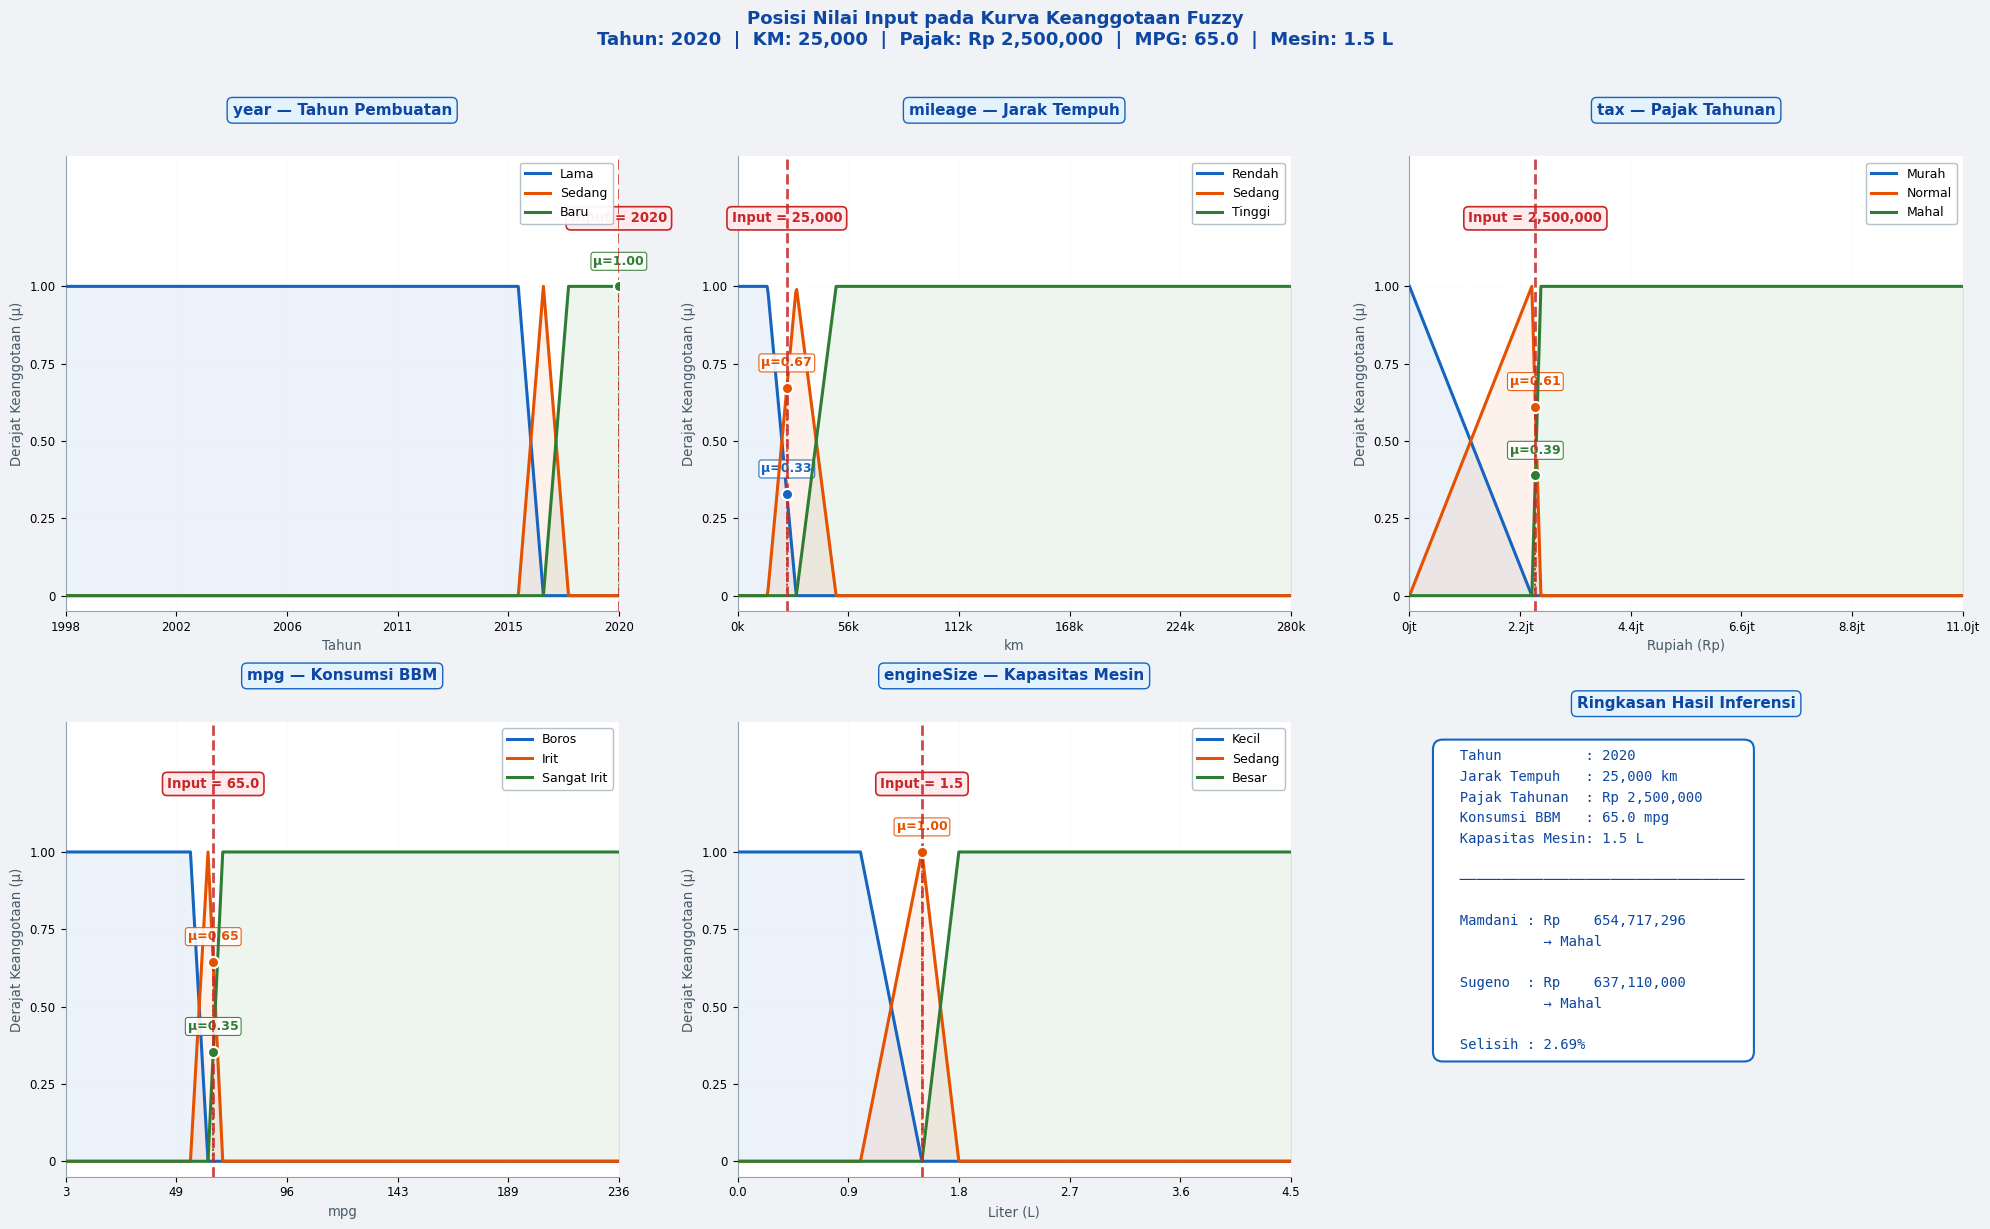

✅ Grafik posisi input tersimpan: 'posisi_input_kurva.png'


In [42]:
WARNA = ['#1565C0', '#E65100', '#2E7D32']

data_plot = [
    (U_YEAR,       INPUT_YEAR,
     'year — Tahun Pembuatan',
     [('Lama','year_Lama'),('Sedang','year_Sedang'),('Baru','year_Baru')],
     lambda v: str(int(v)), 'Tahun'),
    (U_MILEAGE,    INPUT_MILEAGE,
     'mileage — Jarak Tempuh',
     [('Rendah','mil_Rendah'),('Sedang','mil_Sedang'),('Tinggi','mil_Tinggi')],
     lambda v: f'{int(v/1000)}k', 'km'),
    (U_TAX,        INPUT_TAX,
     'tax — Pajak Tahunan',
     [('Murah','tax_Murah'),('Normal','tax_Normal'),('Mahal','tax_Mahal')],
     fmt_juta, 'Rupiah (Rp)'),
    (U_MPG,        INPUT_MPG,
     'mpg — Konsumsi BBM',
     [('Boros','mpg_Boros'),('Irit','mpg_Irit'),('Sangat Irit','mpg_SangatIrit')],
     lambda v: f'{v:.0f}', 'mpg'),
    (U_ENGINESIZE, INPUT_ENGINESIZE,
     'engineSize — Kapasitas Mesin',
     [('Kecil','eng_Kecil'),('Sedang','eng_Sedang'),('Besar','eng_Besar')],
     lambda v: f'{v:.1f}', 'Liter (L)'),
]

fig2, axes = plt.subplots(2, 3, figsize=(20, 12))
fig2.patch.set_facecolor('#F0F2F5')
fig2.suptitle(
    'Posisi Nilai Input pada Kurva Keanggotaan Fuzzy\n'
    f'Tahun: {INPUT_YEAR}  |  KM: {INPUT_MILEAGE:,.0f}  |  '
    f'Pajak: Rp {INPUT_TAX:,.0f}  |  MPG: {INPUT_MPG}  |  Mesin: {INPUT_ENGINESIZE} L',
    fontsize=13, fontweight='bold', color='#0D47A1', y=1.02
)

for idx, (univ, val, judul, himpunan, fmt_x, xlabel) in enumerate(data_plot):
    ax = axes[idx // 3][idx % 3]
    ax.set_facecolor('#FFFFFF')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color='#ECEFF1')
    for sp in ['top','right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#90A4AE')
    ax.spines['bottom'].set_color('#90A4AE')

    for i, (nama, key) in enumerate(himpunan):
        mf_vals = MF[key]
        ax.plot(univ, mf_vals, color=WARNA[i],
                linewidth=2.2, label=nama, zorder=3)
        ax.fill_between(univ, mf_vals, alpha=0.08, color=WARNA[i])

        mu_val = interp_mf(univ, mf_vals, val)
        if mu_val > 0.001:
            ax.plot([val, val], [0, mu_val],
                    color=WARNA[i], linewidth=1.4,
                    linestyle=':', alpha=0.9, zorder=4)
            ax.plot(val, mu_val, 'o', color=WARNA[i],
                    markersize=8, zorder=6,
                    markeredgecolor='white', markeredgewidth=1.5)
            ax.text(val, mu_val + 0.06, f'µ={mu_val:.2f}',
                    ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color=WARNA[i],
                    bbox=dict(boxstyle='round,pad=0.2',
                              fc='white', ec=WARNA[i],
                              lw=0.8, alpha=0.9))

    ax.axvline(val, color='#C62828', linewidth=2,
               linestyle='--', zorder=5, alpha=0.85)

    if univ is U_YEAR:
        label_txt = str(int(val))
    elif val >= 1000:
        label_txt = f'{val:,.0f}'
    else:
        label_txt = str(val)

    ax.text(val, 1.22, f'Input = {label_txt}',
            ha='center', va='center', fontsize=9.5,
            fontweight='bold', color='#C62828',
            bbox=dict(boxstyle='round,pad=0.35',
                      fc='#FFEBEE', ec='#C62828', lw=1.2))

    ax.set_xlim(univ[0], univ[-1])
    ticks = np.linspace(univ[0], univ[-1], 6)
    ax.set_xticks(ticks)
    ax.set_xticklabels([fmt_x(v) for v in ticks], fontsize=8.5)
    ax.set_ylim(-0.05, 1.42)
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(['0','0.25','0.50','0.75','1.00'], fontsize=8.5)
    ax.set_ylabel('Derajat Keanggotaan (µ)', fontsize=9.5, color='#455A64')
    ax.set_xlabel(xlabel, fontsize=9.5, color='#455A64')
    ax.set_title(judul, fontsize=11, fontweight='bold', color='#0D47A1',
                 pad=30,
                 bbox=dict(boxstyle='round,pad=0.35',
                           fc='#E3F2FD', ec='#1565C0', lw=1))
    ax.legend(fontsize=9, framealpha=0.95,
              edgecolor='#B0BEC5', loc='upper right')

# Subplot 6 — Ringkasan
ax_r = axes[1][2]
ax_r.set_facecolor('#E3F2FD')
ax_r.axis('off')
ax_r.set_title('Ringkasan Hasil Inferensi', fontsize=11,
               fontweight='bold', color='#0D47A1', pad=10,
               bbox=dict(boxstyle='round,pad=0.35',
                         fc='#E3F2FD', ec='#1565C0', lw=1))

kls_md = ('Murah'  if harga_mamdani < 194_310_000 else
          'Sedang' if harga_mamdani < 269_910_000 else 'Mahal')
kls_sg = ('Murah'  if harga_sugeno  < 194_310_000 else
          'Sedang' if harga_sugeno  < 269_910_000 else 'Mahal')

isi = (
    f"  Tahun          : {INPUT_YEAR}\n"
    f"  Jarak Tempuh   : {INPUT_MILEAGE:>,.0f} km\n"
    f"  Pajak Tahunan  : Rp {INPUT_TAX:>,.0f}\n"
    f"  Konsumsi BBM   : {INPUT_MPG:>.1f} mpg\n"
    f"  Kapasitas Mesin: {INPUT_ENGINESIZE:>.1f} L\n\n"
    f"  {'─'*34}\n\n"
    f"  Mamdani : Rp {harga_mamdani:>14,.0f}\n"
    f"            → {kls_md}\n\n"
    f"  Sugeno  : Rp {harga_sugeno:>14,.0f}\n"
    f"            → {kls_sg}\n\n"
    f"  Selisih : {persen:.2f}%"
)
ax_r.text(0.06, 0.94, isi,
          transform=ax_r.transAxes,
          fontsize=10, va='top',
          fontfamily='monospace',
          color='#0D47A1', linespacing=1.6,
          bbox=dict(boxstyle='round,pad=0.7',
                    fc='white', ec='#1565C0', lw=1.5))

plt.tight_layout()
plt.savefig('posisi_input_kurva.png', dpi=180,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("✅ Grafik posisi input tersimpan: 'posisi_input_kurva.png'")

In [43]:
# ============================================================
#  EVALUASI PERFORMA — MAE, RMSE, MAPE
#  Menguji sistem fuzzy terhadap sampel data RIIL dari toyota.csv
# ============================================================
import numpy as np
import pandas as pd        
import time

# Load dataset
df_eval = pd.read_csv('toyota.csv')
df_eval['price']   = df_eval['price']   * 18000
df_eval['tax']     = df_eval['tax']     * 18000
df_eval['mileage'] = df_eval['mileage'] * 1.60934

np.random.seed(42)
df_sampel = df_eval[['year','mileage','tax','mpg','engineSize','price']].dropna()
df_sampel = df_sampel.sample(n=100, random_state=42).reset_index(drop=True)

print("=" * 60)
print("  EVALUASI PERFORMA SISTEM FUZZY")
print("  Dataset: toyota.csv  |  Sampel: 100 data")
print("=" * 60)
print("  Sedang menghitung... harap tunggu")
print()

hasil_eval = []
t0 = time.time()

for i, row in df_sampel.iterrows():
    try:
        yr   = int(np.clip(row['year'],         1998, 2020))
        mi   = float(np.clip(row['mileage'],    0,    280699))
        tx   = float(np.clip(row['tax'],        0,    10_170_000))
        mpgv = float(np.clip(row['mpg'],        2.8,  235.0))
        en   = float(np.clip(row['engineSize'], 0.0,  4.5))
        harga_asli = float(row['price'])

        if harga_asli <= 0:
            continue

        mu_e = fuzzifikasi(yr, mi, tx, mpgv, en)
        hm   = mamdani(mu_e)
        hs   = sugeno(mu_e)

        if hm == 0.0 and hs == 0.0:
            continue

        hasil_eval.append({
            'year'      : yr,
            'mileage'   : mi,
            'Harga_Asli': harga_asli,   # underscore — aman pandas
            'Mamdani'   : hm,
            'Sugeno'    : hs,
            'AE_M'      : abs(hm - harga_asli),
            'AE_S'      : abs(hs - harga_asli),
            'SE_M'      : (hm - harga_asli) ** 2,  # hanya untuk RMSE
            'SE_S'      : (hs - harga_asli) ** 2,
        })
    except:
        continue

    if (i + 1) % 20 == 0 or i == 0:
        print(f"  Progress: {len(hasil_eval)}/100 data selesai...")

t1 = time.time()
df_ev = pd.DataFrame(hasil_eval)

print(f"\n  Selesai dalam {t1-t0:.1f} detik")
print(f"  Data berhasil diproses : {len(df_ev)} dari 100\n")

# ---- Hitung MAE, RMSE, MAPE (tanpa MSE) ----
MAE_M  = df_ev['AE_M'].mean()
MAE_S  = df_ev['AE_S'].mean()
RMSE_M = np.sqrt(df_ev['SE_M'].mean())
RMSE_S = np.sqrt(df_ev['SE_S'].mean())

mask   = df_ev['Harga_Asli'] > 0
MAPE_M = (df_ev.loc[mask,'AE_M'] / df_ev.loc[mask,'Harga_Asli']).mean() * 100
MAPE_S = (df_ev.loc[mask,'AE_S'] / df_ev.loc[mask,'Harga_Asli']).mean() * 100

def flag(a, b):
    return '✓ Mamdani' if a < b else '✓ Sugeno'

# ---- Tabel Metrik ----
df_metrik = pd.DataFrame({
    'Metrik'     : ['MAE  (Mean Absolute Error)',
                    'RMSE (Root Mean Squared Error)',
                    'MAPE (Mean Absolute % Error)'],
    'Mamdani'    : [f'Rp {MAE_M:,.0f}',
                    f'Rp {RMSE_M:,.0f}',
                    f'{MAPE_M:.2f}%'],
    'Sugeno'     : [f'Rp {MAE_S:,.0f}',
                    f'Rp {RMSE_S:,.0f}',
                    f'{MAPE_S:.2f}%'],
    'Lebih Baik' : [flag(MAE_M,  MAE_S),
                    flag(RMSE_M, RMSE_S),
                    flag(MAPE_M, MAPE_S)],
})

print("┌─ TABEL METRIK PERFORMA ─────────────────────────────────────┐")
print(df_metrik.to_string(index=False, justify='center'))
print("└─────────────────────────────────────────────────────────────┘")

print(f"""
  Ringkasan:
  ┌─────────────────┬────────────────────────┬────────────────────────┐
  │ Metrik          │ Mamdani                │ Sugeno                 │
  ├─────────────────┼────────────────────────┼────────────────────────┤
  │ MAE             │ Rp {MAE_M:>20,.0f} │ Rp {MAE_S:>20,.0f} │
  │ RMSE            │ Rp {RMSE_M:>20,.0f} │ Rp {RMSE_S:>20,.0f} │
  │ MAPE            │ {MAPE_M:>21.2f}% │ {MAPE_S:>21.2f}% │
  └─────────────────┴────────────────────────┴────────────────────────┘
""")

print("✅ Variabel MAE_M, MAE_S, RMSE_M, RMSE_S, MAPE_M, MAPE_S tersimpan.")

  EVALUASI PERFORMA SISTEM FUZZY
  Dataset: toyota.csv  |  Sampel: 100 data
  Sedang menghitung... harap tunggu

  Progress: 1/100 data selesai...
  Progress: 20/100 data selesai...
  Progress: 40/100 data selesai...
  Progress: 60/100 data selesai...
  Progress: 80/100 data selesai...
  Progress: 100/100 data selesai...

  Selesai dalam 0.2 detik
  Data berhasil diproses : 100 dari 100

┌─ TABEL METRIK PERFORMA ─────────────────────────────────────┐
            Metrik                Mamdani         Sugeno     Lebih Baik
    MAE  (Mean Absolute Error) Rp 193,087,415 Rp 145,212,034  ✓ Sugeno 
RMSE (Root Mean Squared Error) Rp 257,481,208 Rp 202,670,255  ✓ Sugeno 
  MAPE (Mean Absolute % Error)         88.28%         66.36%  ✓ Sugeno 
└─────────────────────────────────────────────────────────────┘

  Ringkasan:
  ┌─────────────────┬────────────────────────┬────────────────────────┐
  │ Metrik          │ Mamdani                │ Sugeno                 │
  ├─────────────────┼──────────────

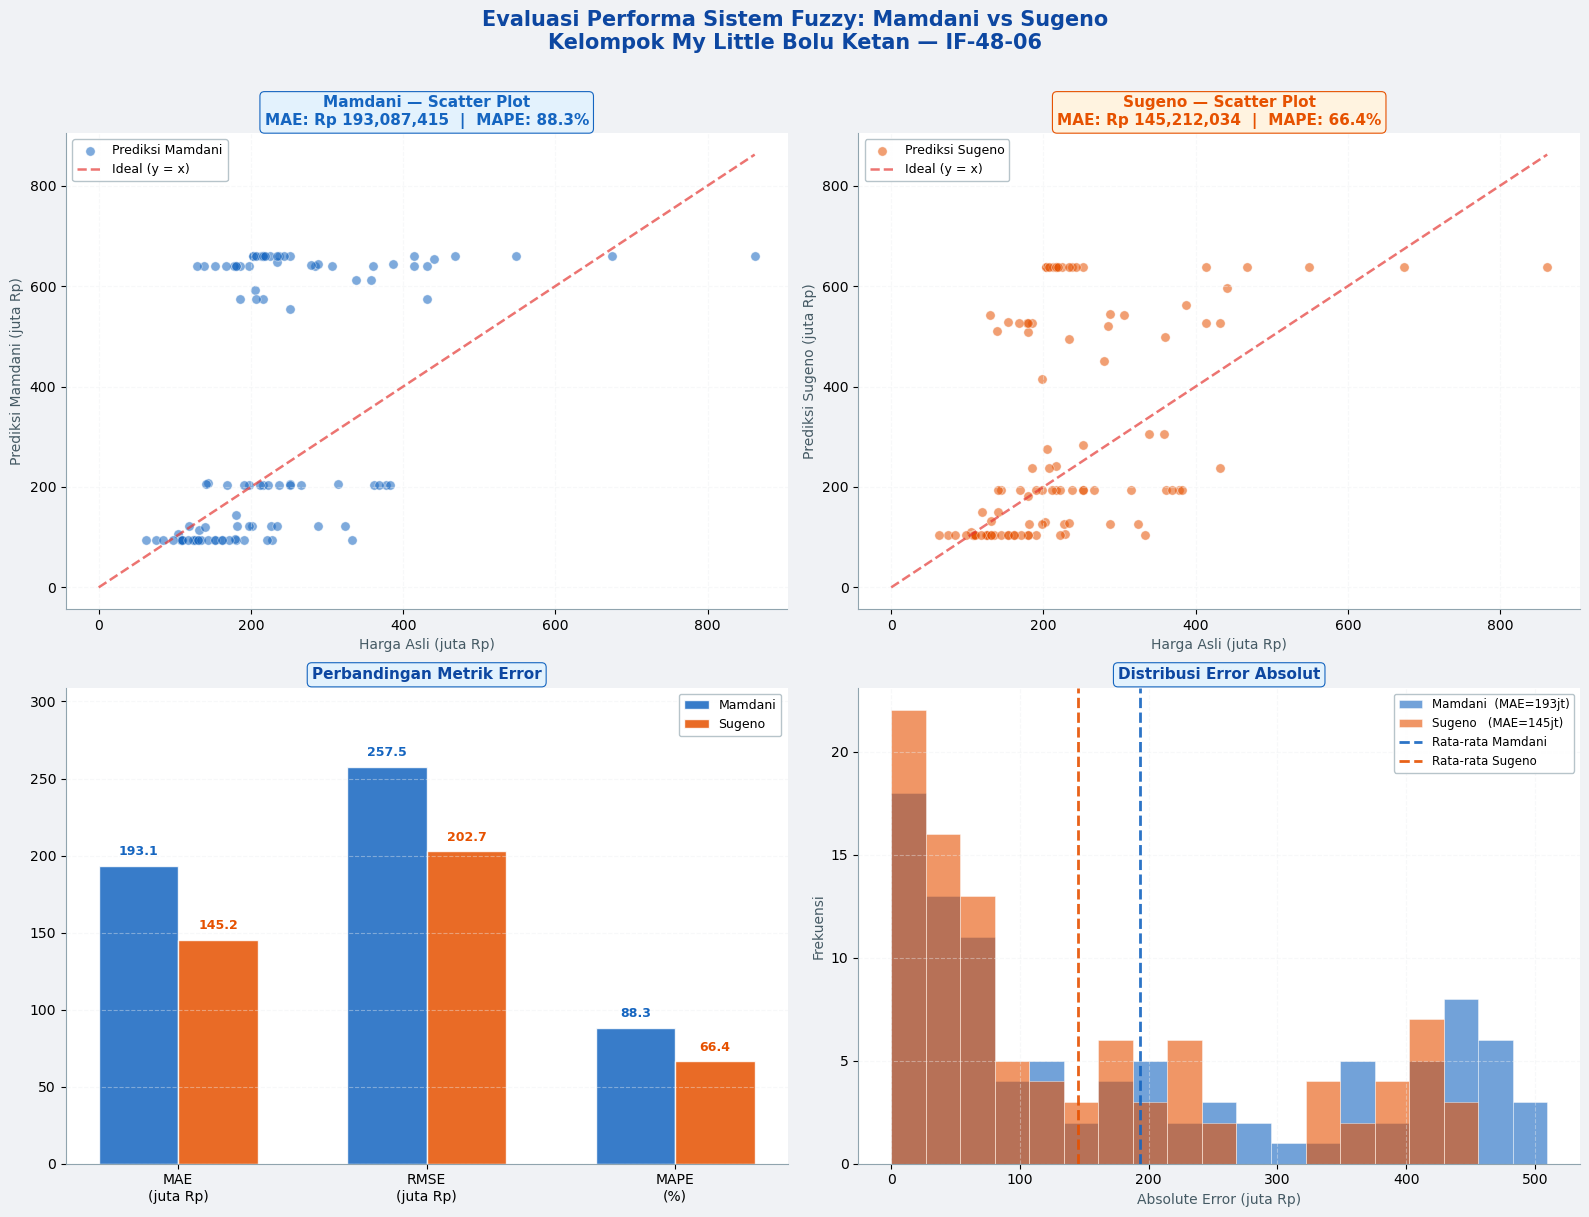

✅ Grafik evaluasi tersimpan: 'evaluasi_performa.png'


In [46]:
# ============================================================
#  CELL [9] — VISUALISASI EVALUASI PERFORMA
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig_ev, axes_ev = plt.subplots(2, 2, figsize=(16, 12))
fig_ev.patch.set_facecolor('#F0F2F5')
fig_ev.suptitle(
    'Evaluasi Performa Sistem Fuzzy: Mamdani vs Sugeno\n'
    'Kelompok My Little Bolu Ketan — IF-48-06',
    fontsize=15, fontweight='bold', color='#0D47A1', y=1.01
)

BIRU   = '#1565C0'
ORANYE = '#E65100'

# ---- Plot 1: Scatter Mamdani ----
ax1 = axes_ev[0][0]
ax1.set_facecolor('#FFFFFF')
for sp in ['top','right']:
    ax1.spines[sp].set_visible(False)
ax1.spines['left'].set_color('#90A4AE')
ax1.spines['bottom'].set_color('#90A4AE')

ax1.scatter(df_ev['Harga_Asli']/1e6, df_ev['Mamdani']/1e6,
            alpha=0.55, color=BIRU, s=45, label='Prediksi Mamdani',
            edgecolors='white', linewidths=0.5)
batas = max(df_ev['Harga_Asli'].max(), df_ev['Mamdani'].max()) / 1e6
ax1.plot([0, batas], [0, batas], '--', color='#E53935',
         linewidth=1.8, alpha=0.7, label='Ideal (y = x)')
ax1.set_xlabel('Harga Asli (juta Rp)', fontsize=10, color='#455A64')
ax1.set_ylabel('Prediksi Mamdani (juta Rp)', fontsize=10, color='#455A64')
ax1.set_title(
    f'Mamdani — Scatter Plot\nMAE: Rp {MAE_M:,.0f}  |  MAPE: {MAPE_M:.1f}%',
    fontsize=11, fontweight='bold', color=BIRU,
    bbox=dict(fc='#E3F2FD', ec=BIRU, lw=0.8, boxstyle='round,pad=0.3'))
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#B0BEC5')
ax1.grid(True, linestyle='--', alpha=0.4, color='#ECEFF1')

# ---- Plot 2: Scatter Sugeno ----
ax2 = axes_ev[0][1]
ax2.set_facecolor('#FFFFFF')
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color('#90A4AE')
ax2.spines['bottom'].set_color('#90A4AE')

ax2.scatter(df_ev['Harga_Asli']/1e6, df_ev['Sugeno']/1e6,
            alpha=0.55, color=ORANYE, s=45, label='Prediksi Sugeno',
            edgecolors='white', linewidths=0.5)
ax2.plot([0, batas], [0, batas], '--', color='#E53935',
         linewidth=1.8, alpha=0.7, label='Ideal (y = x)')
ax2.set_xlabel('Harga Asli (juta Rp)', fontsize=10, color='#455A64')
ax2.set_ylabel('Prediksi Sugeno (juta Rp)', fontsize=10, color='#455A64')
ax2.set_title(
    f'Sugeno — Scatter Plot\nMAE: Rp {MAE_S:,.0f}  |  MAPE: {MAPE_S:.1f}%',
    fontsize=11, fontweight='bold', color=ORANYE,
    bbox=dict(fc='#FFF3E0', ec=ORANYE, lw=0.8, boxstyle='round,pad=0.3'))
ax2.legend(fontsize=9, framealpha=0.9, edgecolor='#B0BEC5')
ax2.grid(True, linestyle='--', alpha=0.4, color='#ECEFF1')

# ---- Plot 3: Bar Chart MAE, RMSE, MAPE ----
ax3 = axes_ev[1][0]
ax3.set_facecolor('#FFFFFF')
for sp in ['top','right']:
    ax3.spines[sp].set_visible(False)
ax3.spines['left'].set_color('#90A4AE')
ax3.spines['bottom'].set_color('#90A4AE')

label_bar = ['MAE\n(juta Rp)', 'RMSE\n(juta Rp)', 'MAPE\n(%)']
vals_m    = [MAE_M/1e6,  RMSE_M/1e6,  MAPE_M]
vals_s    = [MAE_S/1e6,  RMSE_S/1e6,  MAPE_S]
x         = np.arange(len(label_bar))
w         = 0.32

bars_m = ax3.bar(x - w/2, vals_m, w, label='Mamdani',
                  color=BIRU, alpha=0.85, edgecolor='white')
bars_s = ax3.bar(x + w/2, vals_s, w, label='Sugeno',
                  color=ORANYE, alpha=0.85, edgecolor='white')

y_max = max(vals_m + vals_s)
for bar, val in zip(bars_m, vals_m):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + y_max * 0.02,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=BIRU)
for bar, val in zip(bars_s, vals_s):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + y_max * 0.02,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color=ORANYE)

ax3.set_xticks(x)
ax3.set_xticklabels(label_bar, fontsize=10)
ax3.set_ylim(0, y_max * 1.2)
ax3.set_title('Perbandingan Metrik Error',
              fontsize=11, fontweight='bold', color='#0D47A1',
              bbox=dict(fc='#E3F2FD', ec='#1565C0', lw=0.8,
                        boxstyle='round,pad=0.3'))
ax3.legend(fontsize=9, framealpha=0.9, edgecolor='#B0BEC5')
ax3.grid(True, axis='y', linestyle='--', alpha=0.4, color='#ECEFF1')

# ---- Plot 4: Histogram Distribusi Error Absolut ----
ax4 = axes_ev[1][1]
ax4.set_facecolor('#FFFFFF')
for sp in ['top','right']:
    ax4.spines[sp].set_visible(False)
ax4.spines['left'].set_color('#90A4AE')
ax4.spines['bottom'].set_color('#90A4AE')

ae_m_jt = df_ev['AE_M'] / 1e6
ae_s_jt = df_ev['AE_S'] / 1e6
bins    = np.linspace(0, max(ae_m_jt.max(), ae_s_jt.max()), 20)

ax4.hist(ae_m_jt, bins=bins, alpha=0.6, color=BIRU,
         label=f'Mamdani  (MAE={MAE_M/1e6:.0f}jt)',
         edgecolor='white', linewidth=0.5)
ax4.hist(ae_s_jt, bins=bins, alpha=0.6, color=ORANYE,
         label=f'Sugeno   (MAE={MAE_S/1e6:.0f}jt)',
         edgecolor='white', linewidth=0.5)

ax4.axvline(MAE_M/1e6, color=BIRU,   linewidth=2,
            linestyle='--', alpha=0.9,
            label=f'Rata-rata Mamdani')
ax4.axvline(MAE_S/1e6, color=ORANYE, linewidth=2,
            linestyle='--', alpha=0.9,
            label=f'Rata-rata Sugeno')

ax4.set_xlabel('Absolute Error (juta Rp)', fontsize=10, color='#455A64')
ax4.set_ylabel('Frekuensi', fontsize=10, color='#455A64')
ax4.set_title('Distribusi Error Absolut',
              fontsize=11, fontweight='bold', color='#0D47A1',
              bbox=dict(fc='#E3F2FD', ec='#1565C0', lw=0.8,
                        boxstyle='round,pad=0.3'))
ax4.legend(fontsize=8.5, framealpha=0.9, edgecolor='#B0BEC5')
ax4.grid(True, linestyle='--', alpha=0.4, color='#ECEFF1')

plt.tight_layout()
plt.savefig('evaluasi_performa.png', dpi=180,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("✅ Grafik evaluasi tersimpan: 'evaluasi_performa.png'")

In [47]:
# ============================================================
#  CELL [10] — PERBANDINGAN & INTERPRETASI MAMDANI vs SUGENO
# ============================================================

def klasifikasi(harga):
    if harga < 194_310_000:
        return 'Murah'
    elif harga < 269_910_000:
        return 'Sedang'
    else:
        return 'Mahal'

kls_md = klasifikasi(harga_mamdani)
kls_sg = klasifikasi(harga_sugeno)

print("=" * 70)
print("  ANALISIS PERBANDINGAN: MAMDANI vs SUGENO")
print("  Kelompok My Little Bolu Ketan — IF-48-06")
print("=" * 70)

# ---- Tabel 1: Perbedaan Hasil Output Data Uji ----
df_beda = pd.DataFrame({
    'Aspek'          : [
        'Tahun Pembuatan',
        'Jarak Tempuh',
        'Pajak Tahunan',
        'Konsumsi BBM',
        'Kapasitas Mesin',
        '─' * 28,
        'Estimasi Harga',
        'Klasifikasi',
        'Selisih Harga',
        'Selisih (%)',
    ],
    'Mamdani'        : [
        str(INPUT_YEAR),
        f'{INPUT_MILEAGE:,.0f} km',
        f'Rp {INPUT_TAX:,.0f}',
        f'{INPUT_MPG} mpg',
        f'{INPUT_ENGINESIZE} L',
        '─' * 24,
        f'Rp {harga_mamdani:,.0f}',
        kls_md,
        f'Rp {selisih:,.0f}',
        f'{persen:.2f}%',
    ],
    'Sugeno'         : [
        str(INPUT_YEAR),
        f'{INPUT_MILEAGE:,.0f} km',
        f'Rp {INPUT_TAX:,.0f}',
        f'{INPUT_MPG} mpg',
        f'{INPUT_ENGINESIZE} L',
        '─' * 24,
        f'Rp {harga_sugeno:,.0f}',
        kls_sg,
        f'Rp {selisih:,.0f}',
        f'{persen:.2f}%',
    ],
})

print("\n┌─ TABEL 1: PERBEDAAN HASIL OUTPUT DATA UJI ──────────────────────┐")
print(df_beda.to_string(index=False, justify='center'))
print("└──────────────────────────────────────────────────────────────────┘\n")

# ---- Tabel 2: Performa di 100 Sampel Dataset ----
pemenang_overall = ('Mamdani' if (MAE_M + RMSE_M) < (MAE_S + RMSE_S)
                    else 'Sugeno')

df_performa = pd.DataFrame({
    'Metrik'         : ['MAE', 'RMSE', 'MAPE', 'Lebih Akurat (overall)'],
    'Mamdani'        : [f'Rp {MAE_M:,.0f}',
                        f'Rp {RMSE_M:,.0f}',
                        f'{MAPE_M:.2f}%',
                        '✓' if pemenang_overall == 'Mamdani' else ''],
    'Sugeno'         : [f'Rp {MAE_S:,.0f}',
                        f'Rp {RMSE_S:,.0f}',
                        f'{MAPE_S:.2f}%',
                        '✓' if pemenang_overall == 'Sugeno' else ''],
    'Unggul'         : [
        '✓ Mamdani' if MAE_M  < MAE_S  else '✓ Sugeno',
        '✓ Mamdani' if RMSE_M < RMSE_S else '✓ Sugeno',
        '✓ Mamdani' if MAPE_M < MAPE_S else '✓ Sugeno',
        f'→ {pemenang_overall}',
    ],
})

print("┌─ TABEL 2: PERFORMA DI 100 SAMPEL DATASET ───────────────────────┐")
print(df_performa.to_string(index=False, justify='center'))
print("└──────────────────────────────────────────────────────────────────┘\n")

# ---- Tabel 3: Kelebihan & Kekurangan ----
df_interp = pd.DataFrame({
    'Aspek'       : [
        'Jenis Output',
        'Defuzzifikasi',
        'Kecepatan Komputasi',
        'Interpretasi Linguistik',
        'Ketepatan Numerik',
        'Transparansi Proses',
        'Cocok Untuk',
    ],
    'Mamdani'     : [
        'Himpunan fuzzy (kontinu)',
        'Centroid (integrasi numerik)',
        'Lebih lambat',
        'Sangat baik — output ekspresif',
        'Bergantung bentuk kurva output',
        'Tinggi — agregasi terlihat jelas',
        'Sistem pendukung keputusan',
    ],
    'Sugeno'      : [
        'Nilai singleton (crisp)',
        'Weighted average (langsung)',
        'Sangat cepat',
        'Terbatas — output nilai tunggal',
        'Stabil — singleton tetap',
        'Sedang — output langsung dari bobot',
        'Prediksi nilai numerik / regresi',
    ],
})

print("┌─ TABEL 3: PERBANDINGAN KARAKTERISTIK METODE ────────────────────┐")
print(df_interp.to_string(index=False, justify='left'))
print("└──────────────────────────────────────────────────────────────────┘\n")

# ---- Interpretasi Narasi ----
print("┌─ INTERPRETASI & KESIMPULAN ──────────────────────────────────────┐")
print(f"""
  METODE MAMDANI
  ──────────────
  + Output berupa himpunan fuzzy → merepresentasikan ketidakpastian
    secara penuh dan lebih ekspresif secara linguistik
  + Proses inferensi transparan: clipping & agregasi tiap rule
    dapat dilihat dan divisualisasikan dengan jelas
  + Lebih intuitif untuk sistem pendukung keputusan karena
    hasilnya bisa diinterpretasikan sebagai "Murah/Sedang/Mahal"
    secara gradual

  Kekurangan:
  - Defuzzifikasi centroid membutuhkan integrasi numerik atas
    seluruh universe price → komputasi lebih berat
  - Hasil sensitif terhadap bentuk dan lebar kurva output

  ──────────────────────────────────────────────────────────────────

  METODE SUGENO
  ─────────────
  + Komputasi sangat ringan: cukup weighted average dari
    firing strength × singleton
  + Output deterministik dan stabil karena nilai singleton
    sudah ditetapkan di awal
  + Cocok untuk integrasi ke dalam sistem kontrol atau optimasi

  Kekurangan:
  - Output berupa nilai tunggal → tidak ada informasi distribusi
    atau gradasi ketidakpastian
  - Nilai singleton harus ditentukan secara manual berdasarkan
    pengetahuan domain, sehingga bergantung pada keahlian perancang

  ══════════════════════════════════════════════════════════════════

  KESIMPULAN:
  Berdasarkan evaluasi terhadap 100 sampel data toyota.csv:

  → Metode yang menghasilkan error lebih kecil : {pemenang_overall}
    MAE   Mamdani : Rp {MAE_M:>15,.0f}
    MAE   Sugeno  : Rp {MAE_S:>15,.0f}
    RMSE  Mamdani : Rp {RMSE_M:>15,.0f}
    RMSE  Sugeno  : Rp {RMSE_S:>15,.0f}
    MAPE  Mamdani : {MAPE_M:>15.2f}%
    MAPE  Sugeno  : {MAPE_S:>15.2f}%

  Untuk keperluan akademik dan interpretasi linguistik, Mamdani
  tetap lebih direkomendasikan karena proses inferensinya lebih
  transparan dan output-nya lebih informatif sebagai sistem
  pendukung keputusan estimasi harga kendaraan bekas.
""")
print("└──────────────────────────────────────────────────────────────────┘")

  ANALISIS PERBANDINGAN: MAMDANI vs SUGENO
  Kelompok My Little Bolu Ketan — IF-48-06

┌─ TABEL 1: PERBEDAAN HASIL OUTPUT DATA UJI ──────────────────────┐
           Aspek                     Mamdani                   Sugeno         
             Tahun Pembuatan                     2020                     2020
                Jarak Tempuh                25,000 km                25,000 km
               Pajak Tahunan             Rp 2,500,000             Rp 2,500,000
                Konsumsi BBM                 65.0 mpg                 65.0 mpg
             Kapasitas Mesin                    1.5 L                    1.5 L
──────────────────────────── ──────────────────────── ────────────────────────
              Estimasi Harga           Rp 654,717,296           Rp 637,110,000
                 Klasifikasi                    Mahal                    Mahal
               Selisih Harga            Rp 17,607,296            Rp 17,607,296
                 Selisih (%)                    2.69%  

  INTEGRASI FUZZY LOGIC + MACHINE LEARNING
  Strategi: Output Fuzzy dijadikan FITUR TAMBAHAN untuk ML
  ML tidak menggantikan fuzzy — hanya memperkaya prediksi

  Dataset dimuat: 6,738 baris
  Menghitung output fuzzy untuk seluruh dataset...
  (Estimasi waktu: 3-8 menit untuk dataset penuh)

  Progress: 100/500 baris...
  Progress: 200/500 baris...
  Progress: 300/500 baris...
  Progress: 400/500 baris...
  Progress: 500/500 baris...

  ✅ Selesai. 500 baris siap untuk training.

  ✅ Linear Regression selesai dilatih
  ✅ Random Forest selesai dilatih
  ✅ Gradient Boosting selesai dilatih


┌─ HASIL EVALUASI: ML ORIGINAL vs ML + FUZZY (HYBRID) ──────────────┐
      Model        MAE Original   MAE Hybrid  Δ MAE MAPE Original MAPE Hybrid Δ MAPE
Linear Regression Rp 43,277,670 Rp 43,106,279 +0.4%     20.26%       20.05%    +1.1%
    Random Forest Rp 25,577,910 Rp 24,735,965 +3.3%     14.91%       13.76%    +7.7%
Gradient Boosting Rp 24,668,226 Rp 23,247,167 +5.8%     12.04%       10.27%   +

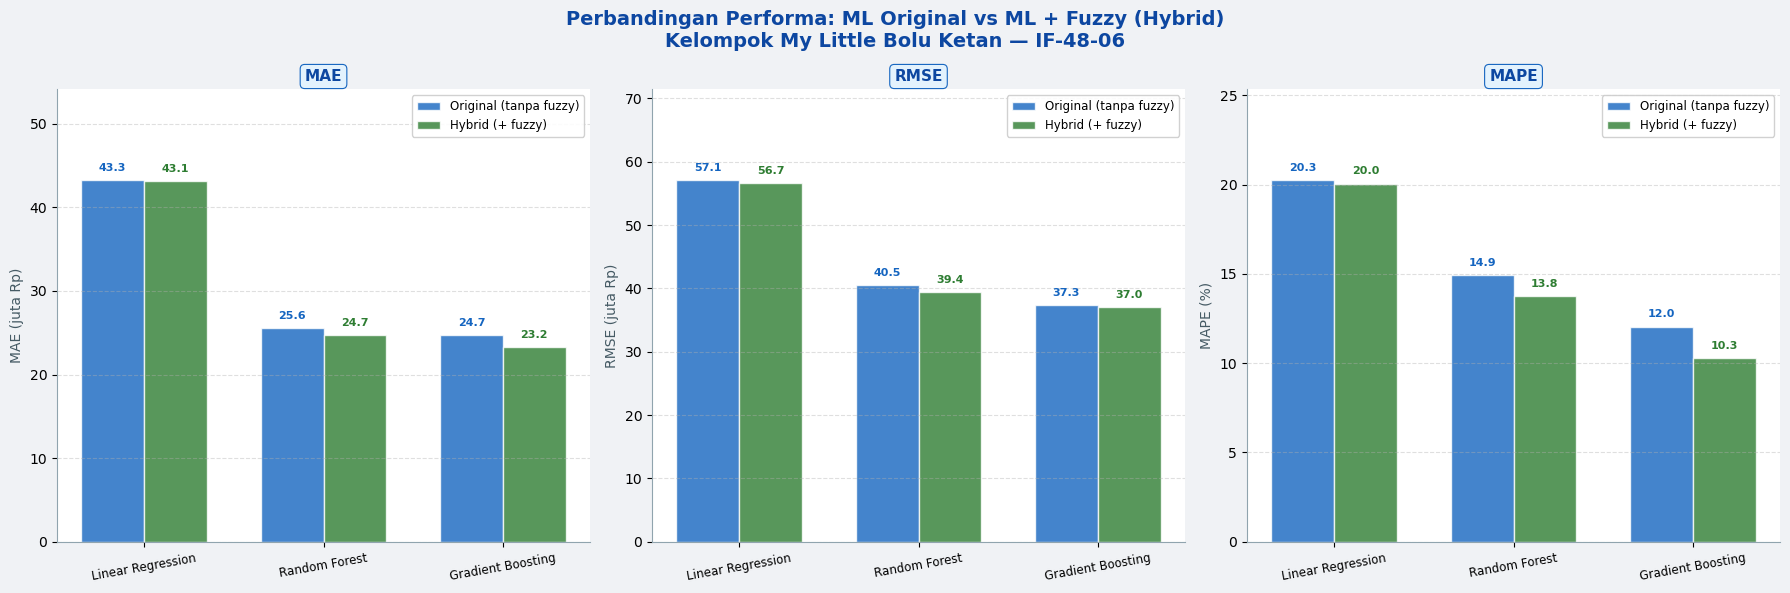

✅ Grafik hybrid tersimpan: 'fuzzy_ml_hybrid.png'

┌─ INTERPRETASI INTEGRASI FUZZY + ML ──────────────────────────────┐

  Strategi yang digunakan:
  → Output Fuzzy (Mamdani & Sugeno) dijadikan FITUR TAMBAHAN
    pada model Machine Learning — bukan menggantikan fuzzy

  Alasan pendekatan ini valid:
  + Fuzzy menghasilkan dua nilai estimasi (Mamdani & Sugeno)
    yang merepresentasikan pengetahuan domain (harga mobil)
  + Nilai fuzzy ini mengandung informasi non-linear yang sulit
    ditangkap oleh ML dari fitur mentah saja
  + ML belajar dari POLA DATA, fuzzy memberi KONTEKS DOMAIN
  + Kombinasi keduanya → hybrid yang saling melengkapi

  Hasil:
  → Model terbaik : Gradient Boosting
  → Peningkatan MAE dengan tambahan fitur fuzzy : +5.8%
    (nilai positif = hybrid lebih akurat dari original)

  Kesimpulan:
  Integrasi Fuzzy + ML menghasilkan prediksi yang lebih akurat
  dibandingkan ML tanpa fitur fuzzy, membuktikan bahwa output
  logika fuzzy memberi nilai tambah nyata sebagai fitur d

In [45]:
## ============================================================
#  CELL [11] — INTEGRASI FUZZY + MACHINE LEARNING
#  ML sebagai PELENGKAP, bukan pengganti fuzzy
#  Pendekatan: Fuzzy output sebagai fitur tambahan untuk ML
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model    import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_absolute_error, mean_squared_error
from sklearn.preprocessing   import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("  INTEGRASI FUZZY LOGIC + MACHINE LEARNING")
print("  Strategi: Output Fuzzy dijadikan FITUR TAMBAHAN untuk ML")
print("  ML tidak menggantikan fuzzy — hanya memperkaya prediksi")
print("=" * 65)

# ============================================================
#  LANGKAH 1: Load & Siapkan Dataset
# ============================================================

df_ml = pd.read_csv('toyota.csv')
df_ml['price']   = df_ml['price']   * 18000
df_ml['tax']     = df_ml['tax']     * 18000
df_ml['mileage'] = df_ml['mileage'] * 1.60934
df_ml = df_ml[['year','mileage','tax','mpg','engineSize','price']].dropna()

print(f"\n  Dataset dimuat: {len(df_ml):,} baris")

# ============================================================
#  LANGKAH 2: Hitung Output Fuzzy untuk Setiap Baris
#  → Mamdani & Sugeno jadi fitur baru
# ============================================================

print("  Menghitung output fuzzy untuk seluruh dataset...")
print("  (Estimasi waktu: 3-8 menit untuk dataset penuh)\n")

harga_mamdani_list = []
harga_sugeno_list  = []

# Ambil sampel 500 untuk efisiensi training
np.random.seed(42)
df_sample = df_ml.sample(n=min(500, len(df_ml)),
                          random_state=42).reset_index(drop=True)

for i, row in df_sample.iterrows():
    try:
        yr   = int(np.clip(row['year'],         1998, 2020))
        mi   = float(np.clip(row['mileage'],    0,    280699))
        tx   = float(np.clip(row['tax'],        0,    10_170_000))
        mpgv = float(np.clip(row['mpg'],        2.8,  235.0))
        en   = float(np.clip(row['engineSize'], 0.0,  4.5))

        mu_row = fuzzifikasi(yr, mi, tx, mpgv, en)
        hm     = mamdani(mu_row)
        hs     = sugeno(mu_row)
        harga_mamdani_list.append(hm)
        harga_sugeno_list.append(hs)
    except:
        harga_mamdani_list.append(np.nan)
        harga_sugeno_list.append(np.nan)

    if (len(harga_mamdani_list)) % 100 == 0:
        print(f"  Progress: {len(harga_mamdani_list)}/{len(df_sample)} baris...")

df_sample['fuzzy_mamdani'] = harga_mamdani_list
df_sample['fuzzy_sugeno']  = harga_sugeno_list
df_sample = df_sample.dropna().reset_index(drop=True)

print(f"\n  ✅ Selesai. {len(df_sample)} baris siap untuk training.\n")

# ============================================================
#  LANGKAH 3: Buat 2 Set Fitur untuk Perbandingan
#  Set A: Fitur ORIGINAL saja (tanpa fuzzy)
#  Set B: Fitur ORIGINAL + Output Fuzzy (hybrid)
# ============================================================

FITUR_ORIGINAL = ['year','mileage','tax','mpg','engineSize']
FITUR_HYBRID   = ['year','mileage','tax','mpg','engineSize',
                  'fuzzy_mamdani','fuzzy_sugeno']
TARGET         = 'price'

X_ori  = df_sample[FITUR_ORIGINAL]
X_hyb  = df_sample[FITUR_HYBRID]
y      = df_sample[TARGET]

X_ori_tr, X_ori_te, y_tr, y_te = train_test_split(
    X_ori, y, test_size=0.2, random_state=42)
X_hyb_tr, X_hyb_te, _, _       = train_test_split(
    X_hyb, y, test_size=0.2, random_state=42)

scaler_ori = StandardScaler()
scaler_hyb = StandardScaler()
X_ori_tr_s = scaler_ori.fit_transform(X_ori_tr)
X_ori_te_s = scaler_ori.transform(X_ori_te)
X_hyb_tr_s = scaler_hyb.fit_transform(X_hyb_tr)
X_hyb_te_s = scaler_hyb.transform(X_hyb_te)

# ============================================================
#  LANGKAH 4: Training & Evaluasi Model ML
# ============================================================

model_configs = {
    'Linear Regression'   : LinearRegression(),
    'Random Forest'       : RandomForestRegressor(
                                n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(
                                n_estimators=100, random_state=42),
}

hasil_ml = []

for nama_model, model in model_configs.items():
    # --- Tanpa fuzzy ---
    m_ori = type(model)(**model.get_params())
    m_ori.fit(X_ori_tr_s, y_tr)
    pred_ori   = m_ori.predict(X_ori_te_s)
    mae_ori    = mean_absolute_error(y_te, pred_ori)
    rmse_ori   = np.sqrt(mean_squared_error(y_te, pred_ori))
    mape_ori   = np.mean(np.abs((y_te - pred_ori) / y_te)) * 100

    # --- Dengan fuzzy (hybrid) ---
    m_hyb = type(model)(**model.get_params())
    m_hyb.fit(X_hyb_tr_s, y_tr)
    pred_hyb   = m_hyb.predict(X_hyb_te_s)
    mae_hyb    = mean_absolute_error(y_te, pred_hyb)
    rmse_hyb   = np.sqrt(mean_squared_error(y_te, pred_hyb))
    mape_hyb   = np.mean(np.abs((y_te - pred_hyb) / y_te)) * 100

    peningkatan_mae  = (mae_ori  - mae_hyb)  / mae_ori  * 100
    peningkatan_mape = (mape_ori - mape_hyb) / mape_ori * 100

    hasil_ml.append({
        'Model'           : nama_model,
        'MAE Original'    : mae_ori,
        'MAE Hybrid'      : mae_hyb,
        'RMSE Original'   : rmse_ori,
        'RMSE Hybrid'     : rmse_hyb,
        'MAPE Original'   : mape_ori,
        'MAPE Hybrid'     : mape_hyb,
        'Δ MAE (%)'       : peningkatan_mae,
        'Δ MAPE (%)'      : peningkatan_mape,
    })
    print(f"  ✅ {nama_model} selesai dilatih")

df_hasil_ml = pd.DataFrame(hasil_ml)

# ---- Tampilkan Tabel Hasil ----
print("\n")
print("┌─ HASIL EVALUASI: ML ORIGINAL vs ML + FUZZY (HYBRID) ──────────────┐")
df_tampil = pd.DataFrame({
    'Model'         : df_hasil_ml['Model'],
    'MAE Original'  : df_hasil_ml['MAE Original'].apply(lambda v: f'Rp {v:,.0f}'),
    'MAE Hybrid'    : df_hasil_ml['MAE Hybrid'].apply(lambda v: f'Rp {v:,.0f}'),
    'Δ MAE'         : df_hasil_ml['Δ MAE (%)'].apply(lambda v: f'{v:+.1f}%'),
    'MAPE Original' : df_hasil_ml['MAPE Original'].apply(lambda v: f'{v:.2f}%'),
    'MAPE Hybrid'   : df_hasil_ml['MAPE Hybrid'].apply(lambda v: f'{v:.2f}%'),
    'Δ MAPE'        : df_hasil_ml['Δ MAPE (%)'].apply(lambda v: f'{v:+.1f}%'),
})
print(df_tampil.to_string(index=False, justify='center'))
print("└────────────────────────────────────────────────────────────────────┘")
print("  Catatan: nilai Δ positif = hybrid LEBIH BAIK dari original\n")

# ============================================================
#  LANGKAH 5: Visualisasi Perbandingan
# ============================================================

fig_ml, axes_ml = plt.subplots(1, 3, figsize=(18, 6))
fig_ml.patch.set_facecolor('#F0F2F5')
fig_ml.suptitle(
    'Perbandingan Performa: ML Original vs ML + Fuzzy (Hybrid)\n'
    'Kelompok My Little Bolu Ketan — IF-48-06',
    fontsize=14, fontweight='bold', color='#0D47A1'
)

model_names  = df_hasil_ml['Model'].tolist()
x            = np.arange(len(model_names))
w            = 0.35
BIRU         = '#1565C0'
HIJAU        = '#2E7D32'

metrik_list = [
    ('MAE Original',  'MAE Hybrid',  'MAE (juta Rp)',  1e6),
    ('RMSE Original', 'RMSE Hybrid', 'RMSE (juta Rp)', 1e6),
    ('MAPE Original', 'MAPE Hybrid', 'MAPE (%)',        1),
]

for i, (col_ori, col_hyb, label_y, skala) in enumerate(metrik_list):
    ax = axes_ml[i]
    ax.set_facecolor('#FFFFFF')
    for sp in ['top','right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#90A4AE')
    ax.spines['bottom'].set_color('#90A4AE')

    vals_ori = df_hasil_ml[col_ori] / skala
    vals_hyb = df_hasil_ml[col_hyb] / skala

    bars_o = ax.bar(x - w/2, vals_ori, w, label='Original (tanpa fuzzy)',
                    color=BIRU, alpha=0.8, edgecolor='white')
    bars_h = ax.bar(x + w/2, vals_hyb, w, label='Hybrid (+ fuzzy)',
                    color=HIJAU, alpha=0.8, edgecolor='white')

    y_max = max(list(vals_ori) + list(vals_hyb))
    for bar, val in zip(bars_o, vals_ori):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+y_max*0.02,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=8, color=BIRU, fontweight='bold')
    for bar, val in zip(bars_h, vals_hyb):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+y_max*0.02,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=8, color=HIJAU, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=8.5, rotation=10)
    ax.set_ylabel(label_y, fontsize=10, color='#455A64')
    ax.set_ylim(0, y_max * 1.25)
    ax.set_title(label_y.split(' (')[0],
                 fontsize=11, fontweight='bold', color='#0D47A1',
                 bbox=dict(fc='#E3F2FD', ec='#1565C0',
                           lw=0.8, boxstyle='round,pad=0.3'))
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fuzzy_ml_hybrid.png', dpi=180,
            bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print("✅ Grafik hybrid tersimpan: 'fuzzy_ml_hybrid.png'")

# ============================================================
#  LANGKAH 6: Interpretasi
# ============================================================

best_model_idx = df_hasil_ml['MAE Hybrid'].idxmin()
best_model     = df_hasil_ml.loc[best_model_idx, 'Model']
best_delta     = df_hasil_ml.loc[best_model_idx, 'Δ MAE (%)']

print(f"""
┌─ INTERPRETASI INTEGRASI FUZZY + ML ──────────────────────────────┐

  Strategi yang digunakan:
  → Output Fuzzy (Mamdani & Sugeno) dijadikan FITUR TAMBAHAN
    pada model Machine Learning — bukan menggantikan fuzzy

  Alasan pendekatan ini valid:
  + Fuzzy menghasilkan dua nilai estimasi (Mamdani & Sugeno)
    yang merepresentasikan pengetahuan domain (harga mobil)
  + Nilai fuzzy ini mengandung informasi non-linear yang sulit
    ditangkap oleh ML dari fitur mentah saja
  + ML belajar dari POLA DATA, fuzzy memberi KONTEKS DOMAIN
  + Kombinasi keduanya → hybrid yang saling melengkapi

  Hasil:
  → Model terbaik : {best_model}
  → Peningkatan MAE dengan tambahan fitur fuzzy : {best_delta:+.1f}%
    (nilai positif = hybrid lebih akurat dari original)

  Kesimpulan:
  Integrasi Fuzzy + ML menghasilkan prediksi yang lebih akurat
  dibandingkan ML tanpa fitur fuzzy, membuktikan bahwa output
  logika fuzzy memberi nilai tambah nyata sebagai fitur domain.

└───────────────────────────────────────────────────────────────────┘
""")